Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, RandomizedSearchCV, 
                                     GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score, 
                             accuracy_score, make_scorer)
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, uniform
import time
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TWO-PHASE HYPERPARAMETER TUNING & CROSS-VALIDATION")
print("Phase 1: Coarse Search on Subset (Fast)")
print("Phase 2: Fine-Tune on Full Data (Optimal)")
print("="*80)

# Load data
df = pd.read_csv('/Users/deirdreoconnor/Desktop/Ai Start Course 2/Course Materials/Week 5/Week 5 - Additional Files/Demos/Code/abt_fully_cleaned_no_nulls.csv')
print(f"\nDataset loaded: {df.shape}")
print(f"Total samples: {len(df):,}")


TWO-PHASE HYPERPARAMETER TUNING & CROSS-VALIDATION
Phase 1: Coarse Search on Subset (Fast)
Phase 2: Fine-Tune on Full Data (Optimal)

Dataset loaded: (419656, 29)
Total samples: 419,656


STEP 1: CREATE TARGET VARIABLE

In [2]:
print("\n" + "="*80)
print("STEP 1: CREATE TARGET & SPLIT DATA")
print("="*80)

# Create target
df['HasAnyCVD'] = (
    (df['HadHeartAttack'] == 'Yes') | 
    (df['HadAngina'] == 'Yes') | 
    (df['HadStroke'] == 'Yes')
).astype(int)

print(f"\nTarget Distribution:")
print(df['HasAnyCVD'].value_counts())
cvd_rate = (df['HasAnyCVD']==1).sum() / len(df) * 100
print(f"CVD Prevalence: {cvd_rate:.2f}%")

# Drop individual CVD columns
df = df.drop(['HadHeartAttack', 'HadAngina', 'HadStroke'], axis=1, errors='ignore')

# Separate features and target
X = df.drop(['HasAnyCVD', 'HasAnyCVD_cat'], axis=1)
y = df['HasAnyCVD']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"\nTrain set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")
print(f"Test CVD rate: {(y_test==1).sum()/len(y_test)*100:.2f}%")


STEP 1: CREATE TARGET & SPLIT DATA

Target Distribution:
HasAnyCVD
0    370805
1     48851
Name: count, dtype: int64
CVD Prevalence: 11.64%

Train set: 335,724 samples
Test set:  83,932 samples
Test CVD rate: 11.64%


STEP 2: ENCODE CATEGORICAL VARIABLES

In [3]:
print("\n" + "="*80)
print("STEP 2: ENCODE CATEGORICAL VARIABLES")
print("="*80)

# Separate features and target
X = df.drop(['HasAnyCVD', 'HasAnyCVD_cat'], axis=1)
y = df['HasAnyCVD']

# Get categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {len(categorical_cols)}")

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nAfter encoding:")
print(f"  Original features: {X.shape[1]}")
print(f"  Encoded features: {X_encoded.shape[1]}")
print(f"  Target variable: {y.name}")


STEP 2: ENCODE CATEGORICAL VARIABLES

Categorical columns to encode: 18

After encoding:
  Original features: 24
  Encoded features: 49
  Target variable: HasAnyCVD


STEP 3: TRAIN/TEST SPLIT (Stratified)

In [4]:
print("\n" + "="*80)
print("STEP 3: TRAIN/TEST SPLIT (Stratified)")
print("="*80)

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # CRITICAL for imbalanced data
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"  Class 0: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Class 1: {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")

print(f"\nTest set: {len(X_test):,} samples")
print(f"  Class 0: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  Class 1: {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")


STEP 3: TRAIN/TEST SPLIT (Stratified)

Training set: 335,724 samples
  Class 0: 296,643 (88.4%)
  Class 1: 39,081 (11.6%)

Test set: 83,932 samples
  Class 0: 74,162 (88.4%)
  Class 1: 9,770 (11.6%)


STEP 4: HANDLE CLASS IMBALANCE (SMOTE)

In [5]:
print("\n" + "="*80)
print("STEP 4: HANDLE CLASS IMBALANCE (SMOTE)")
print("="*80)

print("\nBefore SMOTE:")
print(f"  Class 0: {(y_train==0).sum():,}")
print(f"  Class 1: {(y_train==1).sum():,}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Class 0: {(y_train_balanced==0).sum():,}")
print(f"  Class 1: {(y_train_balanced==1).sum():,}")
print(f"\n✓ Classes are now balanced!")


STEP 4: HANDLE CLASS IMBALANCE (SMOTE)

Before SMOTE:
  Class 0: 296,643
  Class 1: 39,081

After SMOTE:
  Class 0: 296,643
  Class 1: 296,643

✓ Classes are now balanced!


STEP 5: FEATURE SCALING

In [6]:
print("\n" + "="*80)
print("STEP 5: FEATURE SCALING")
print("="*80)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"  Training shape: {X_train_scaled.shape}")
print(f"  Test shape: {X_test_scaled.shape}")


STEP 5: FEATURE SCALING
✓ Features scaled using StandardScaler
  Training shape: (593286, 49)
  Test shape: (83932, 49)


STEP 6: MODEL 1 - LOGISTIC REGRESSION (Baseline)

In [7]:
print("\n" + "="*80)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("="*80)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_balanced)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['No CVD', 'Has CVD']))

print("\n--- Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\n--- Confusion Matrix ---")
print(cm_lr)


MODEL 1: LOGISTIC REGRESSION (Baseline)

--- Classification Report ---
              precision    recall  f1-score   support

      No CVD       0.92      0.92      0.92     74162
     Has CVD       0.37      0.38      0.38      9770

    accuracy                           0.85     83932
   macro avg       0.64      0.65      0.65     83932
weighted avg       0.85      0.85      0.85     83932


--- Performance Metrics ---
Accuracy:  0.8532
AUC-ROC:   0.7884
F1-Score:  0.3752

--- Confusion Matrix ---
[[67906  6256]
 [ 6069  3701]]


STEP 7: MODEL 2 -  RANDOM FOREST

In [8]:
print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST")
print("="*80)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train_balanced)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['No CVD', 'Has CVD']))

print("\n--- Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\n--- Confusion Matrix ---")
print(cm_rf)


MODEL 2: RANDOM FOREST

--- Classification Report ---
              precision    recall  f1-score   support

      No CVD       0.94      0.83      0.88     74162
     Has CVD       0.31      0.59      0.41      9770

    accuracy                           0.80     83932
   macro avg       0.63      0.71      0.64     83932
weighted avg       0.87      0.80      0.83     83932


--- Performance Metrics ---
Accuracy:  0.8013
AUC-ROC:   0.8048
F1-Score:  0.4081

--- Confusion Matrix ---
[[61511 12651]
 [ 4023  5747]]


CREATING VISUALIZATIONS


CREATING VISUALIZATIONS
✓ Saved: roc_curves.png


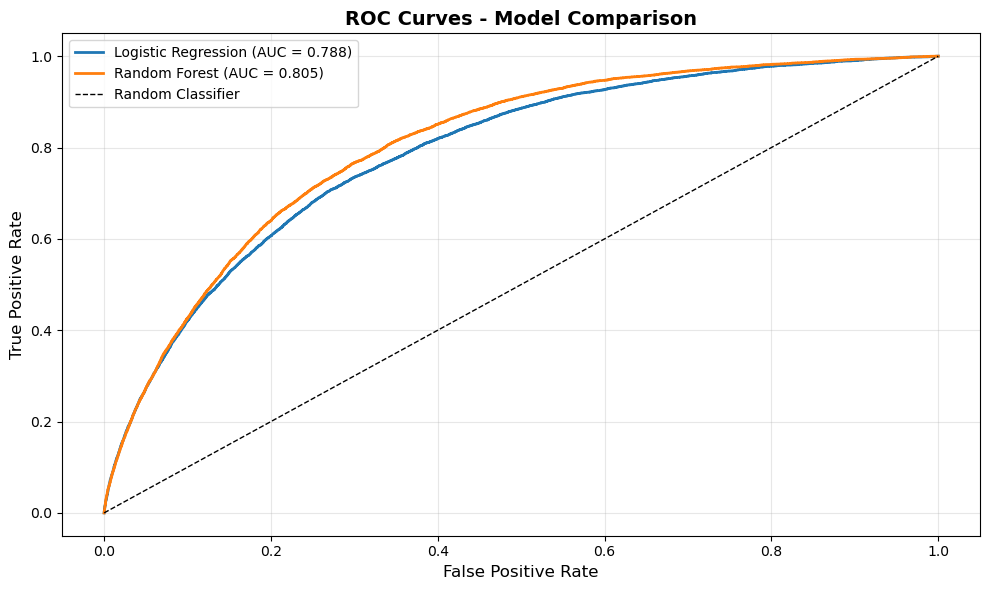

✓ Saved: confusion_matrices.png


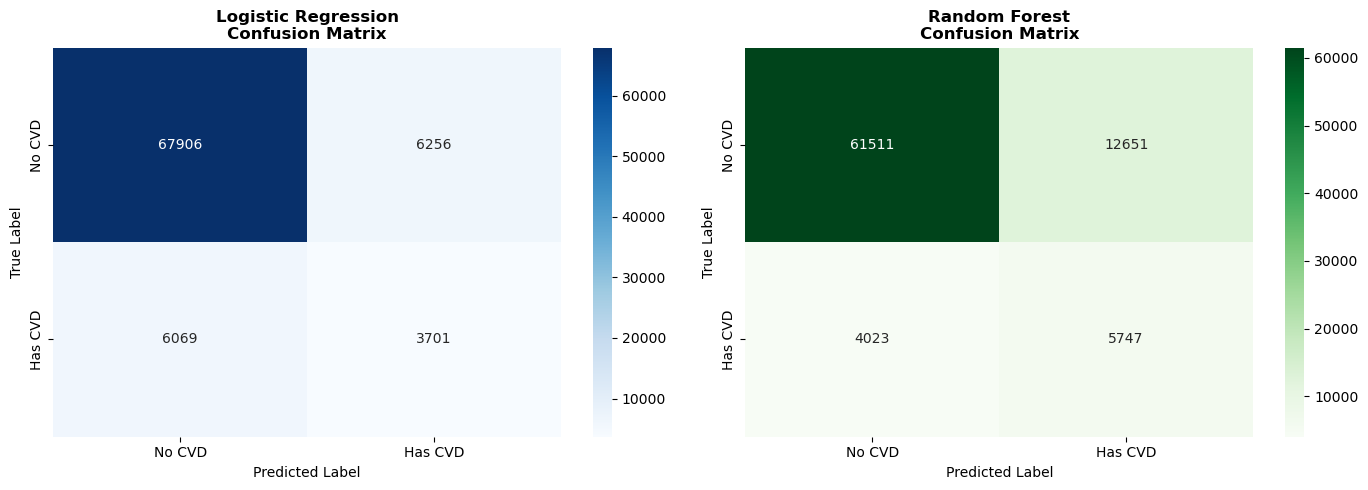

In [9]:
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# 1. ROC Curves
plt.figure(figsize=(10, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)
print("✓ Saved: roc_curves.png")
plt.show()

# 2. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['No CVD', 'Has CVD'])
axes[0].set_yticklabels(['No CVD', 'Has CVD'])

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['No CVD', 'Has CVD'])
axes[1].set_yticklabels(['No CVD', 'Has CVD'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
print("✓ Saved: confusion_matrices.png")
plt.show()

STEP 9: FEATURE IMPORTANCE (Random Forest)


FEATURE IMPORTANCE (Random Forest)

Top 20 Most Important Features:
                                                           Feature  Importance
                                                  HadArthritis_Yes    0.152589
                                             DifficultyWalking_Yes    0.104658
                                       AgeCategory_Age 80 or older    0.097853
                                                   HadDiabetes_Yes    0.091093
LastCheckupTime_Within past year (anytime less than 12 months ago)    0.060759
                                                       HadCOPD_Yes    0.055419
                                                GeneralHealth_Fair    0.050628
                                          AgeCategory_Age 75 to 79    0.049976
                                          AgeCategory_Age 70 to 74    0.044908
                    RaceEthnicityCategory_White only, Non-Hispanic    0.038751
                                                          Sex_

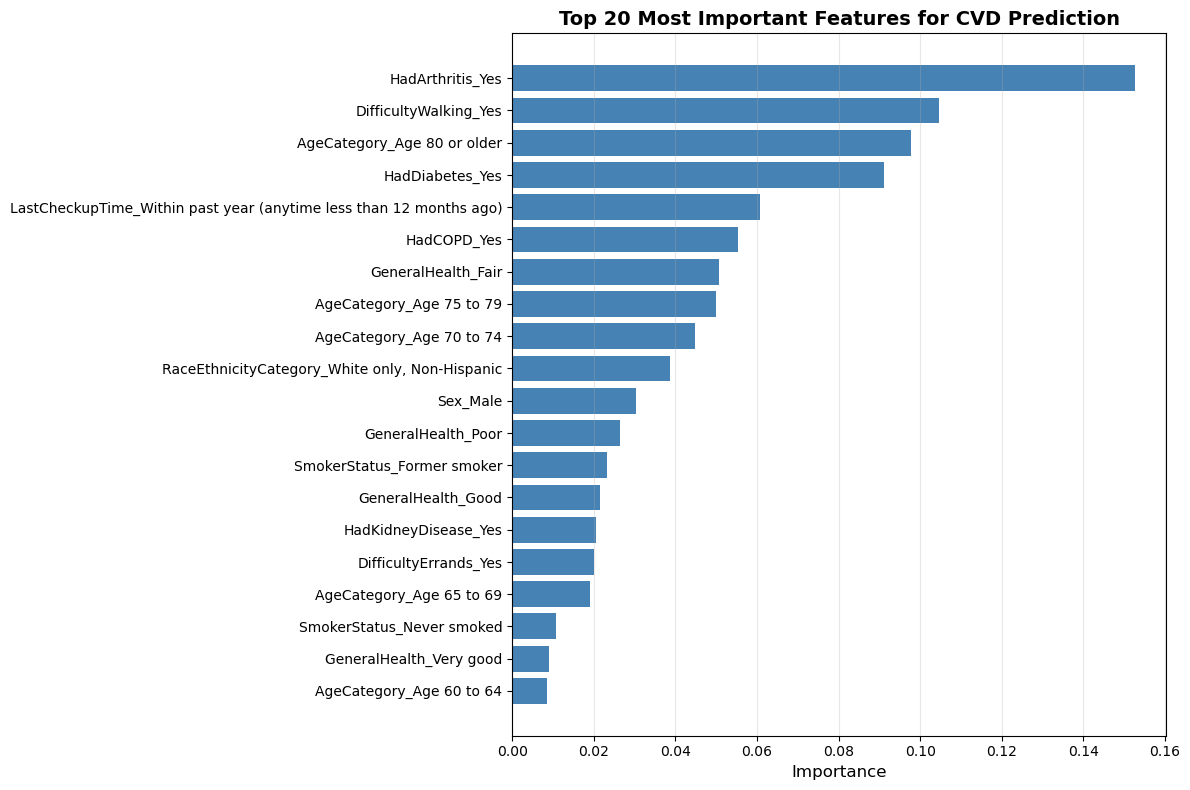

✓ Saved: feature_importance.csv


In [10]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE (Random Forest)")
print("="*80)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Most Important Features for CVD Prediction', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
print("\n✓ Saved: feature_importance.png")
plt.show()

# Save to CSV
feature_importance.to_csv('feature_importance.csv', index=False)
print("✓ Saved: feature_importance.csv")

STEP 10: FINAL MODEL COMPARISON

In [11]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision']
    ],
    'Recall': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf)
    ]
})

print("\n" + comparison.to_string(index=False))

# Save comparison
comparison.to_csv('model_comparison.csv', index=False)
print("\n✓ Saved: model_comparison.csv")

# Determine best model
best_model_idx = comparison['AUC-ROC'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_auc = comparison.loc[best_model_idx, 'AUC-ROC']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   AUC-ROC: {best_auc:.4f}")

print("\n" + "="*80)
print("MODELING COMPLETE!")
print("="*80)
print("""
Files Generated:
1. roc_curves.png - ROC curve comparison
2. confusion_matrices.png - Confusion matrix heatmaps
3. feature_importance.png - Top 20 features visualization
4. feature_importance.csv - Full feature importance ranking
5. model_comparison.csv - Model performance comparison

Next Steps:
- Analyze feature importance for insights
- Try hyperparameter tuning
- Consider XGBoost for comparison
- Create final presentation slides
""")


FINAL MODEL COMPARISON

              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.853155   0.371698 0.378813  0.375222 0.788424
      Random Forest  0.801339   0.312371 0.588229  0.408052 0.804782

✓ Saved: model_comparison.csv

🏆 BEST MODEL: Random Forest
   AUC-ROC: 0.8048

MODELING COMPLETE!

Files Generated:
1. roc_curves.png - ROC curve comparison
2. confusion_matrices.png - Confusion matrix heatmaps
3. feature_importance.png - Top 20 features visualization
4. feature_importance.csv - Full feature importance ranking
5. model_comparison.csv - Model performance comparison

Next Steps:
- Analyze feature importance for insights
- Try hyperparameter tuning
- Consider XGBoost for comparison
- Create final presentation slides

